In [57]:
!pip install ollama

Loading IMDb dataset...
Sampled 100 reviews from IMDb test set
Positive reviews: 53
Negative reviews: 47

Defining prompting strategies...

Running the experiment...

Running Zero-Shot prompting strategy...


  0%|          | 0/100 [00:00<?, ?it/s]

Error getting prediction: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}
Error getting prediction: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}
Error getting prediction: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficien

  0%|          | 0/100 [00:00<?, ?it/s]

Error getting prediction: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}
Error getting prediction: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}
Error getting prediction: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficien

  0%|          | 0/100 [00:00<?, ?it/s]

Error getting prediction: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}
Error getting prediction: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}
Error getting prediction: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficien

<ipython-input-59-ff585a42378d>:214: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


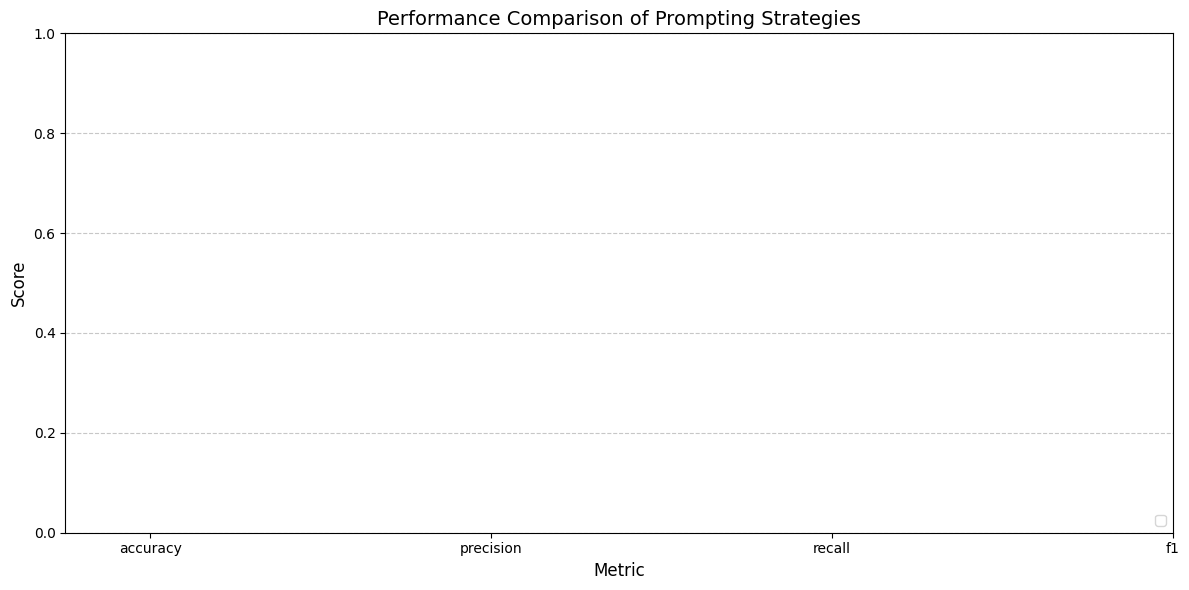

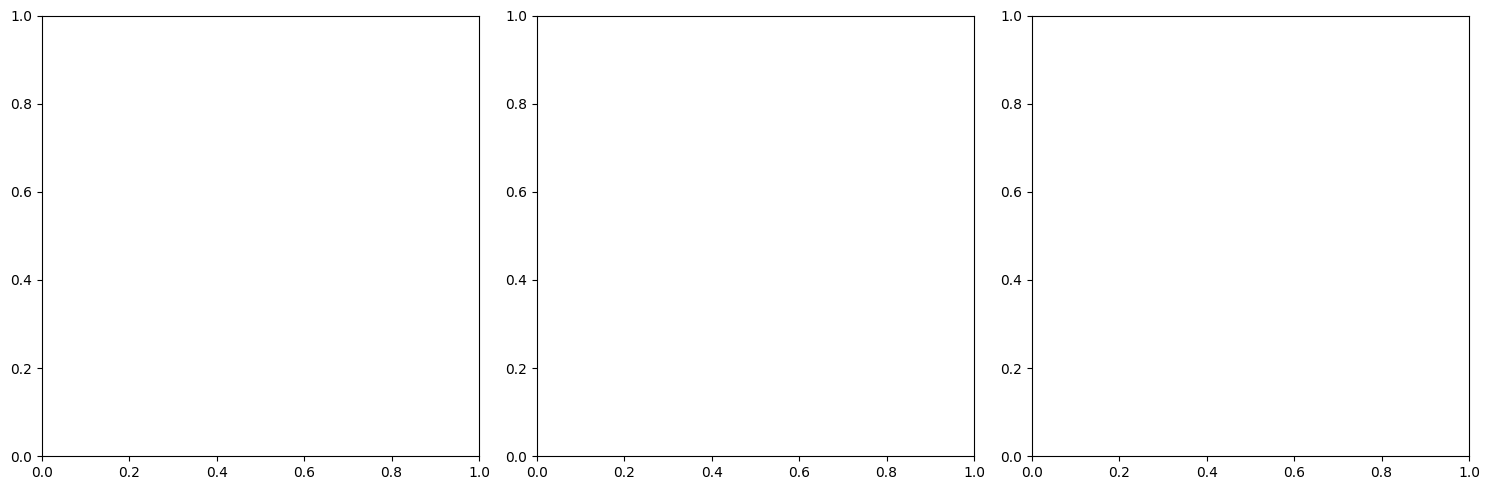


Summary of Findings:
--------------------


ValueError: max() arg is an empty sequence

In [59]:
# First, install the required libraries
!pip install datasets transformers openai tqdm seaborn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from datasets import load_dataset
from tqdm.notebook import tqdm
import random
import seaborn as sns
import os
import time
from openai import OpenAI

# Set seed for reproducibility
random.seed(42)
np.random.seed(42)

# Set up OpenAI API key - you'll need to provide this
# In Colab, for security, you can use environment variables or Colab secrets
# For demonstration, we're using a cell magic to get user input
from google.colab import userdata
openai_api_key = userdata.get('OPENAI_API_KEY')
# If the above doesn't work, you can uncomment and run the following line
# openai_api_key = input("Enter your OpenAI API key: ")

client = OpenAI(api_key=openai_api_key)

# 1. Load IMDb dataset
print("Loading IMDb dataset...")
imdb = load_dataset("imdb")

# Convert to pandas for easier handling
train_df = pd.DataFrame(imdb['train'])
test_df = pd.DataFrame(imdb['test'])

# Sample a small subset for quick demonstration
sample_size = 100
test_samples = test_df.sample(sample_size, random_state=42)
print(f"Sampled {sample_size} reviews from IMDb test set")
print(f"Positive reviews: {sum(test_samples['label'] == 1)}")
print(f"Negative reviews: {sum(test_samples['label'] == 0)}")

# 2. Define the prompting strategies
print("\nDefining prompting strategies...")

# Zero-shot prompt (just task description)
zero_shot_prompt = """
Classify the sentiment of the following movie review as either POSITIVE or NEGATIVE.
Review: {review}
Sentiment:
"""

# One-shot prompt (task description + one example)
one_shot_prompt = """
Classify the sentiment of the following movie review as either POSITIVE or NEGATIVE.
Example:
Review: This film was absolutely incredible! The acting was superb and the plot kept me engaged throughout.
Sentiment: POSITIVE
Now classify this review:
Review: {review}
Sentiment:
"""

# Few-shot prompt (task description + multiple examples)
few_shot_prompt = """
Classify the sentiment of the following movie review as either POSITIVE or NEGATIVE.
Example 1:
Review: This film was absolutely incredible! The acting was superb and the plot kept me engaged throughout.
Sentiment: POSITIVE
Example 2:
Review: I was extremely disappointed by this movie. The characters were poorly developed and the story made no sense.
Sentiment: NEGATIVE
Example 3:
Review: While it had some redeeming qualities like the cinematography, overall the movie fell flat with its predictable storyline.
Sentiment: NEGATIVE
Example 4:
Review: I thoroughly enjoyed this film. The director's vision was clear and the performances were compelling.
Sentiment: POSITIVE
Now classify this review:
Review: {review}
Sentiment:
"""

# 3. Function to get prediction from OpenAI API instead of Ollama
def get_sentiment_prediction(review_text, prompt_template, model_name='gpt-3.5-turbo'):
    """Get sentiment prediction using OpenAI API with the specified prompt strategy"""
    try:
        # Format the prompt with the review
        full_prompt = prompt_template.format(review=review_text)

        # Call OpenAI API
        response = client.chat.completions.create(
            model=model_name,
            messages=[
                {"role": "user", "content": full_prompt}
            ],
            temperature=0
        )

        # Extract prediction text
        prediction_text = response.choices[0].message.content.strip().upper()

        # Convert to binary label
        if 'POSITIVE' in prediction_text:
            return 1
        elif 'NEGATIVE' in prediction_text:
            return 0
        else:
            # If can't determine, return None
            print(f"Couldn't determine sentiment from: {prediction_text}")
            return None
    except Exception as e:
        print(f"Error getting prediction: {e}")
        time.sleep(2)  # Rate limit handling
        return None

# 4. Run the experiment for all three prompting strategies
print("\nRunning the experiment...")

# Dictionary to store results for each strategy
results = {}

# List of strategies to test
strategies = {
    'Zero-Shot': zero_shot_prompt,
    'One-Shot': one_shot_prompt,
    'Few-Shot': few_shot_prompt
}

# Process each strategy
for strategy_name, prompt_template in strategies.items():
    print(f"\nRunning {strategy_name} prompting strategy...")

    # Store predictions and true labels
    predictions = []
    true_labels = []

    # Process each review in the test set
    for idx, row in tqdm(test_samples.iterrows(), total=len(test_samples)):
        # Get the review text and true label
        review = row['text']
        true_label = row['label']

        # Truncate long reviews to keep inference faster and cheaper
        if len(review) > 500:
            review = review[:500] + "..."

        # Get prediction
        prediction = get_sentiment_prediction(review, prompt_template)

        # Store if valid prediction
        if prediction is not None:
            predictions.append(prediction)
            true_labels.append(true_label)

        # Add a small delay to avoid rate limits
        time.sleep(0.5)

    # Calculate metrics
    if predictions:
        accuracy = accuracy_score(true_labels, predictions)
        precision, recall, f1, _ = precision_recall_fscore_support(
            true_labels, predictions, average='binary', zero_division=0
        )

        # Store results
        results[strategy_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'predictions': predictions,
            'true_labels': true_labels
        }

        print(f"{strategy_name} Results:")
        print(f" Accuracy: {accuracy:.4f}")
        print(f" Precision: {precision:.4f}")
        print(f" Recall: {recall:.4f}")
        print(f" F1 Score: {f1:.4f}")
    else:
        print(f"No valid predictions for {strategy_name}")

# 5. Visualize the results
print("\nVisualizing results...")

# Prepare data for visualization
metrics = ['accuracy', 'precision', 'recall', 'f1']
strategies_list = list(results.keys())

# Create a bar chart comparing all metrics across strategies
plt.figure(figsize=(12, 6))

# Prepare positions for bars
x = np.arange(len(metrics))
width = 0.25  # Width of bars
multiplier = 0

# Plot bars for each strategy
for strategy_name, result in results.items():
    offset = width * multiplier
    values = [result[metric] for metric in metrics]
    plt.bar(x + offset, values, width, label=strategy_name)
    multiplier += 1

# Add labels and legend
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Performance Comparison of Prompting Strategies', fontsize=14)
plt.xticks(x + width, metrics)
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for i, strategy_name in enumerate(results.keys()):
    for j, metric in enumerate(metrics):
        value = results[strategy_name][metric]
        plt.text(j + (i * width), value + 0.02, f"{value:.2f}",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('prompting_strategies_comparison.png')
plt.show()

# 6. Plot confusion matrices for better insight
fig, axes = plt.subplots(1, len(strategies), figsize=(15, 5))

# Handle the case when there's only one strategy
if len(strategies) == 1:
    axes = [axes]

for i, (strategy_name, result) in enumerate(results.items()):
    # Create a confusion matrix
    conf_matrix = np.zeros((2, 2))
    for pred, true in zip(result['predictions'], result['true_labels']):
        conf_matrix[true, pred] += 1

    # Plot heatmap
    sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                ax=axes[i])
    axes[i].set_title(f'{strategy_name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('prompting_strategies_confusion_matrices.png')
plt.show()

# 7. Summary of findings
print("\nSummary of Findings:")
print("--------------------")

# Calculate improvements
if 'Zero-Shot' in results and 'Few-Shot' in results:
    zero_to_few_improvement = (results['Few-Shot']['accuracy'] - results['Zero-Shot']['accuracy']) * 100
    print(f"• Few-Shot shows {zero_to_few_improvement:.2f}% accuracy improvement over Zero-Shot")

if 'One-Shot' in results and 'Few-Shot' in results:
    one_to_few_improvement = (results['Few-Shot']['accuracy'] - results['One-Shot']['accuracy']) * 100
    print(f"• Few-Shot shows {one_to_few_improvement:.2f}% accuracy improvement over One-Shot")

# Find best strategy
best_strategy = max(results, key=lambda x: results[x]['accuracy'])
print(f"• Best performing strategy: {best_strategy} with {results[best_strategy]['accuracy']:.4f} accuracy")

print("\nExperiment completed!")

# Optional: Save results to file
import json

# Convert numpy values to native Python types for JSON serialization
serializable_results = {}
for strategy, metrics in results.items():
    serializable_results[strategy] = {
        'accuracy': float(metrics['accuracy']),
        'precision': float(metrics['precision']),
        'recall': float(metrics['recall']),
        'f1': float(metrics['f1']),
        # Skip predictions and true_labels as they're just arrays of 0s and 1s
    }

with open('prompting_results.json', 'w') as f:
    json.dump(serializable_results, f, indent=2)